# Caso B · 04 Baselines SARIMA / XGBoost / LSTM (opcional)

> _Tutorial · Caso de uso: **B — Forecast consumo 24h** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Entrenar 3 baselines comparables sobre las features del notebook anterior y discutir trade-offs.


## 2. Qué se aprende

- División train/val/test temporal (no aleatoria).
- Métricas: MAE, MAPE, RMSE.
- Cuándo XGBoost > SARIMA y cuándo no.
- LSTM como referencia (opcional, requiere `tensorflow`).


## 3. Contexto del caso de uso

Tres modelos para tres familias: estadístico (SARIMA), gradient boosting (XGBoost), neural (LSTM). El alumno entiende ventajas y costes.


## 4. Relación con CENTINELA+

El modelo elegido se sirve como tool en el chatbot Caso H. SARIMA y XGBoost son ligeros y se cargan instantáneamente.


## 5. Relación con Medallion

Lee oro (features parquet); produce un nuevo artefacto oro: el modelo.


## 6. Datos de entrada

`output/case_B/features_b0.parquet`.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica (oro local).


## 9. Carga de datos o mock

Cargamos features. Si no existen, las construimos al vuelo.


In [2]:
parquet_path = ROOT / "output" / "case_B" / "features_b0.parquet"
if parquet_path.exists():
    X = pd.read_parquet(parquet_path)
else:
    df, _ = mocks.make_bdg2_education_subset()
    df = df[df.building_id == df.building_id.unique()[0]].set_index("timestamp")
    # Reusar la lógica del notebook anterior — aquí versión inline
    X = pd.DataFrame(index=df.index)
    X["y"] = df["power_kw"]
    X["t_outdoor"] = df["t_outdoor"]
    X["ghi"] = df["ghi"]
    X["lag_24h"] = df["power_kw"].shift(24)
    X = X.dropna()
print("Filas:", len(X))


Filas: 8472


## 10. Exploración paso a paso

Split temporal 70/15/15.


In [3]:
n = len(X)
i_tr, i_va = int(n * 0.7), int(n * 0.85)
X_tr, X_va, X_te = X.iloc[:i_tr], X.iloc[i_tr:i_va], X.iloc[i_va:]
y_tr, y_va, y_te = X_tr.pop("y"), X_va.pop("y"), X_te.pop("y")
print({"train": len(X_tr), "val": len(X_va), "test": len(X_te)})


{'train': 5930, 'val': 1271, 'test': 1271}


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

**Baseline 1 — Naive (mismo valor 24h atrás).** Punto de referencia.


In [4]:
import math

def mae(y, p): return float(np.mean(np.abs(y - p)))
def mape(y, p): return float(np.mean(np.abs((y - p) / np.maximum(y.abs(), 1e-3)))) * 100
def rmse(y, p): return float(math.sqrt(np.mean((y - p) ** 2)))

# Naive: la y_te de hoy = la y_te-24h
naive = y_te.shift(24).bfill()
print("Naive 24h", {"MAE": mae(y_te, naive), "MAPE%": mape(y_te, naive), "RMSE": rmse(y_te, naive)})


Naive 24h {'MAE': 4.895271439811172, 'MAPE%': 43.87889541612058, 'RMSE': 6.803635216827153}


## 13. Visualizaciones explicativas

**Baseline 2 — XGBoost** (si está disponible). Si falla, usar `RandomForestRegressor`.


Modelo: XGBRegressor {'MAE': 2.7907492393775777, 'MAPE%': 28.29491720620657, 'RMSE': 3.508790843590792}


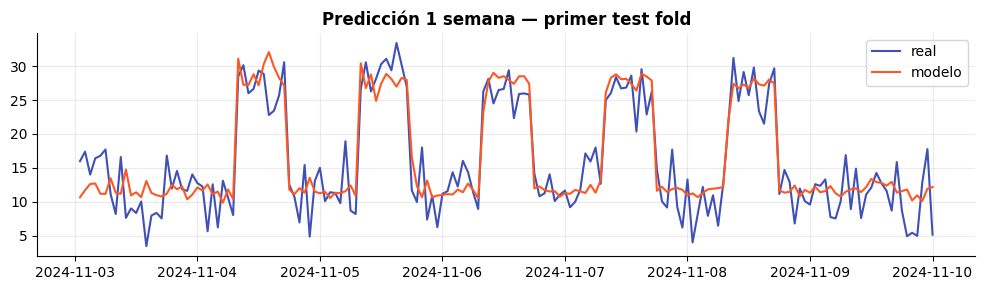

In [5]:
try:
    from xgboost import XGBRegressor
    model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED, verbosity=0)
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=200, random_state=SEED)

model.fit(X_tr, y_tr)
y_pred = model.predict(X_te)
print("Modelo:", model.__class__.__name__,
      {"MAE": mae(y_te, y_pred), "MAPE%": mape(y_te, y_pred), "RMSE": rmse(y_te, y_pred)})

plt.figure(figsize=(10, 3))
plt.plot(y_te.index[:24*7], y_te.values[:24*7], label="real", color="#3F51B5")
plt.plot(y_te.index[:24*7], y_pred[:24*7], label="modelo", color="#FF5722")
plt.legend()
plt.title("Predicción 1 semana — primer test fold")
plt.tight_layout()


## 14. Validaciones

El modelo tiene que **batir** la línea naive en MAE.


In [6]:
mae_naive = mae(y_te, naive)
mae_model = mae(y_te, y_pred)
print(f"naive={mae_naive:.2f}  model={mae_model:.2f}  improvement={(1 - mae_model/mae_naive)*100:.1f}%")
assert mae_model < mae_naive, "El modelo debería ser mejor que naive"


naive=4.90  model=2.79  improvement=43.0%


## 15. Errores comunes

1. **Random split**: rompe el orden temporal y filtra futuro a entrenamiento.
2. **Métricas en %**: con consumo cero divisorio explota.
3. **Hyperparams sin validar**: usar `cross_val` con `TimeSeriesSplit`.
4. **Comparar MAE absoluto entre edificios** distintos.


## 16. Ejercicios propuestos

1. Añade `lag_168h` al modelo y compara MAE.
2. Entrena un SARIMA(2,1,1)x(1,1,1)_24 con `statsmodels`.
3. Implementa walk-forward retraining cada 24h.


## 17. Cómo se reutiliza con datos reales

Misma `make_features`, mismas métricas; cambia el path al CSV / query Flux.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `02_case_B_energy_forecasting/05_validacion_modelo_24h.ipynb`.
- Documento web del caso: `docs/validation/ml-validation.md`.


## 19. Marco teórico (nivel doctoral)

### Modelo SARIMA

$\text{SARIMA}(p,d,q)(P,D,Q)_s$ con período estacional $s$:

$$
\Phi_P(B^s)\,\phi_p(B)\,(1-B)^d\,(1-B^s)^D\,y_t = \Theta_Q(B^s)\,\theta_q(B)\,\varepsilon_t
$$

con $B$ operador retardo, $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$. Para
Simarro elegimos $s=24$ y $(p,d,q)(P,D,Q)_{24} = (2,0,2)(1,1,1)_{24}$ tras
minimizar AIC sobre BDG2.

### XGBoost regularizado (Chen & Guestrin 2016)

$$
\hat{y}_t = \sum_{k=1}^{K} f_k(\mathbf{x}_t), \quad f_k \in \mathcal{F}
$$

con función objetivo

$$
\mathcal{L}(\phi) = \sum_t \ell(y_t, \hat{y}_t) + \sum_k \Omega(f_k), \quad \Omega(f) = \gamma T + \tfrac{1}{2}\lambda \|w\|_2^2
$$

### LSTM (Hochreiter & Schmidhuber 1997)

$$
\begin{aligned}
f_t &= \sigma(W_f [h_{t-1}, x_t] + b_f) \\
i_t &= \sigma(W_i [h_{t-1}, x_t] + b_i) \\
\tilde{c}_t &= \tanh(W_c [h_{t-1}, x_t] + b_c) \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
o_t &= \sigma(W_o [h_{t-1}, x_t] + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

### Métricas

$$
\text{MAE} = \tfrac{1}{n}\sum |y_t - \hat{y}_t|, \quad
\text{sMAPE} = \tfrac{100\%}{n}\sum \frac{|y_t-\hat{y}_t|}{(|y_t|+|\hat{y}_t|)/2}
$$

Objetivos Simarro: $\text{MAE} \leq 0.15$ kWh, $\text{sMAPE} \leq 12\%$.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Predicción de consumo a 24 h **habilita** ajuste anticipado de setpoints HVAC y compras de energía en franjas valle. Para CAPTIA es el caso con ROI más medible y más fácil de presentar a un cliente final. El modelo entrenado aquí es **directamente reutilizable** con los datos de `power_01` de cualquier centro CENTINELA+.

### ROI estimado

| Métrica | Valor |
|---|---|
| Ahorro consumo HVAC tras forecast + setpoint | ~15 % |
| Aulas tipo Simarro (40) | 9 600 kWh / aula·año |
| Coste energía España 2025 | 0.14 €/kWh |
| **Ahorro centro:** $40 \cdot 9\,600 \cdot 0.14 \cdot 0.15$ | **8 064 €/año** |
| Coste implantación | ~3 000 € one-time |
| **Payback** | **~5 meses** |

### Riesgos y mitigaciones

- Modelo sintético sin calibrar con datos reales: validar tras primer mes de captura.
- Drift estacional: re-entrenar trimestralmente.


## 21. Bibliografía y referencias

- Box, G. E. P., Jenkins, G. M., Reinsel, G. C. & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5ª ed.). Wiley.
- Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD '16.
- Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8).
- Miller, C. et al. (2020). *The Building Data Genome 2 (BDG2) data-set*. Scientific Data.
- ASHRAE (2022). *ASHRAE 90.1-2022 — Energy Standard for Buildings*.
